<a href="https://colab.research.google.com/github/Travis-Bickle10/bangalore-air-quality/blob/main/02_merra2_fetch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install earthaccess xarray netCDF4 -q

In [ ]:
import earthaccess
import xarray as xr
import netCDF4

print("earthaccess:", earthaccess.__version__)
print("xarray:", xr.__version__)
print("netCDF4:", netCDF4.__version__)

earthaccess: 0.17.0
xarray: 2025.12.0
netCDF4: 1.7.4


In [ ]:
results = earthaccess.search_data(
    short_name="M2T1NXAER",
    temporal=("2000-01-01", "2017-12-31"),
    bounding_box=(77.5, 12.8, 77.7, 13.1),  # Bangalore bbox (west, south, east, north)
)

print(f"Files found: {len(results)}")
print("Sample file:", results[0])

Files found: 6575
Sample file: Collection: {'ShortName': 'M2T1NXAER', 'Version': '5.12.4'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2000-01-01T00:00:00.000Z', 'EndingDateTime': '2000-01-01T23:59:59.000Z'}}
Size(MB): 481.0720376968384
Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2T1NXAER.5.12.4/2000/01/MERRA2_200.tavg1_2d_aer_Nx.20000101.nc4']


/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:364: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  Size(MB): {self.size()}


In [ ]:
!pip install earthaccess xarray netCDF4 h5netcdf -q

import earthaccess
import xarray as xr
from google.colab import userdata, drive

drive.mount("/content/drive")

# Login
from google.colab import userdata
nasa_user = userdata.get("NASA_USER")
nasa_pass = userdata.get("NASA_PASS")

with open("/root/.netrc", "w") as f:
    f.write(f"machine urs.earthdata.nasa.gov\n")
    f.write(f"login {nasa_user}\n")
    f.write(f"password {nasa_pass}\n")

import os
os.chmod("/root/.netrc", 0o600)
earthaccess.login(strategy="netrc")

# Fetch one file to inspect
results = earthaccess.search_data(
    short_name="M2T1NXAER",
    temporal=("2019-01-01", "2019-01-28"),
    count=1
)
files = earthaccess.open(results[:1])
ds = xr.open_dataset(files[0], engine="h5netcdf")

print("Variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Variables: ['BCANGSTR', 'BCCMASS', 'BCEXTTAU', 'BCFLUXU', 'BCFLUXV', 'BCSCATAU', 'BCSMASS', 'DMSCMASS', 'DMSSMASS', 'DUANGSTR', 'DUCMASS', 'DUCMASS25', 'DUEXTT25', 'DUEXTTAU', 'DUFLUXU', 'DUFLUXV', 'DUSCAT25', 'DUSCATAU', 'DUSMASS', 'DUSMASS25', 'OCANGSTR', 'OCCMASS', 'OCEXTTAU', 'OCFLUXU', 'OCFLUXV', 'OCSCATAU', 'OCSMASS', 'SO2CMASS', 'SO2SMASS', 'SO4CMASS', 'SO4SMASS', 'SSANGSTR', 'SSCMASS', 'SSCMASS25', 'SSEXTT25', 'SSEXTTAU', 'SSFLUXU', 'SSFLUXV', 'SSSCAT25', 'SSSCATAU', 'SSSMASS', 'SSSMASS25', 'SUANGSTR', 'SUEXTTAU', 'SUFLUXU', 'SUFLUXV', 'SUSCATAU', 'TOTANGSTR', 'TOTEXTTAU', 'TOTSCATAU']
Coordinates: ['lon', 'lat', 'time']


In [ ]:
!pip install h5netcdf -q

ds = xr.open_dataset(files[0], engine="h5netcdf")
print("Variables available:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

Variables available: ['BCANGSTR', 'BCCMASS', 'BCEXTTAU', 'BCFLUXU', 'BCFLUXV', 'BCSCATAU', 'BCSMASS', 'DMSCMASS', 'DMSSMASS', 'DUANGSTR', 'DUCMASS', 'DUCMASS25', 'DUEXTT25', 'DUEXTTAU', 'DUFLUXU', 'DUFLUXV', 'DUSCAT25', 'DUSCATAU', 'DUSMASS', 'DUSMASS25', 'OCANGSTR', 'OCCMASS', 'OCEXTTAU', 'OCFLUXU', 'OCFLUXV', 'OCSCATAU', 'OCSMASS', 'SO2CMASS', 'SO2SMASS', 'SO4CMASS', 'SO4SMASS', 'SSANGSTR', 'SSCMASS', 'SSCMASS25', 'SSEXTT25', 'SSEXTTAU', 'SSFLUXU', 'SSFLUXV', 'SSSCAT25', 'SSSCATAU', 'SSSMASS', 'SSSMASS25', 'SUANGSTR', 'SUEXTTAU', 'SUFLUXU', 'SUFLUXV', 'SUSCATAU', 'TOTANGSTR', 'TOTEXTTAU', 'TOTSCATAU']
Coordinates: ['lon', 'lat', 'time']


In [ ]:
# Slice to Bangalore bounding box
LAT_MIN, LAT_MAX = 12.8, 13.1
LON_MIN, LON_MAX = 77.5, 77.7

blr = ds.sel(
    lat=slice(LAT_MIN, LAT_MAX),
    lon=slice(LON_MIN, LON_MAX)
)

# Check how many grid cells we got
print(f"Lat cells: {len(blr.lat.values)} → {blr.lat.values}")
print(f"Lon cells: {len(blr.lon.values)} → {blr.lon.values}")

# Extract PM2.5 proxy — convert kg/m³ to µg/m³ (multiply by 1e9)
pm25 = (blr["DUSMASS25"] + blr["OCSMASS"] + blr["BCSMASS"]) * 1e9
so2  = blr["SO2SMASS"] * 1e9

# Average across grid cells and time steps (24 hourly values → daily mean)
print(f"\nDate: 2000-01-01")
print(f"PM2.5 proxy: {float(pm25.mean()):,.2f} µg/m³")
print(f"SO2:         {float(so2.mean()):,.2f} µg/m³")

ds.close()

Lat cells: 1 → [13.]
Lon cells: 1 → [77.5]

Date: 2000-01-01
PM2.5 proxy: 12.39 µg/m³
SO2:         2.48 µg/m³


In [ ]:
# Check all PM2.5 components separately
files2 = earthaccess.open(results[:1])
ds2 = xr.open_dataset(files2[0], engine="h5netcdf")
blr2 = ds2.sel(
    lat=slice(12.8, 13.1),
    lon=slice(77.5, 77.7)
)

components = {
    "Dust (DUSMASS25)":           float(blr2["DUSMASS25"].mean()) * 1e9,
    "Organic carbon (OCSMASS)":   float(blr2["OCSMASS"].mean())   * 1e9,
    "Black carbon (BCSMASS)":     float(blr2["BCSMASS"].mean())   * 1e9,
    "Sea salt (SSSMASS25)":       float(blr2["SSSMASS25"].mean()) * 1e9,
    "SO2 (SO2SMASS)":             float(blr2["SO2SMASS"].mean())  * 1e9,
}

for name, val in components.items():
    print(f"  {name}: {val:.4f} µg/m³")

print(f"\n  Total PM2.5 proxy: {sum(components.values()):.4f} µg/m³")
ds2.close()

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  Dust (DUSMASS25): 2.3145 µg/m³
  Organic carbon (OCSMASS): 8.1675 µg/m³
  Black carbon (BCSMASS): 1.9089 µg/m³
  Sea salt (SSSMASS25): 1.4118 µg/m³
  SO2 (SO2SMASS): 2.4759 µg/m³

  Total PM2.5 proxy: 16.2785 µg/m³


In [ ]:
# Always run this first — installs reset on every session
!pip install earthaccess xarray netCDF4 h5netcdf -q

import earthaccess
import xarray as xr
import numpy as np
import pandas as pd

earthaccess.login(strategy="netrc")
print("Ready")

Ready


In [ ]:
# Bangalore bounding box
LAT = slice(12.8, 13.1)
LON = slice(77.5, 77.7)

VARS = ["DUSMASS25", "OCSMASS", "BCSMASS", "SSSMASS25", "SO2SMASS", "CO"]
SEASONS = [1, 4, 7, 10]

merra2_rows = []

for year in range(2000, 2026):
    print(f"Fetching {year}...", end=" ")
    year_vals = {v: [] for v in VARS}

    for month in SEASONS:
        try:
            results = earthaccess.search_data(
                short_name="M2T1NXAER",
                temporal=(f"{year}-{month:02d}-01",
                          f"{year}-{month:02d}-28"),
                count=1
            )
            if not results:
                continue

            files = earthaccess.open(results[:1])
            ds = xr.open_dataset(files[0], engine="h5netcdf")
            blr = ds.sel(lat=LAT, lon=LON)

            for v in VARS:
                if v in blr:
                    val = float(blr[v].mean()) * 1e9
                    year_vals[v].append(val)

            ds.close()

        except Exception as e:
            print(f"\n  Error {year}-{month:02d}: {e}")
            continue

    # Average across 4 seasons
    row = {"year": year}
    for v in VARS:
        row[v] = round(np.mean(year_vals[v]), 4) if year_vals[v] else None

    # PM2.5 proxy
    pm25_components = ["DUSMASS25", "OCSMASS", "BCSMASS", "SSSMASS25"]
    vals = [row[v] for v in pm25_components if row[v] is not None]
    row["pm25_proxy"] = round(sum(vals), 4) if vals else None

    # Safe print
    pm25_str = f"{row['pm25_proxy']:.2f}" if row["pm25_proxy"] else "N/A"
    so2_str  = f"{row['SO2SMASS']:.4f}"   if row["SO2SMASS"]  else "N/A"
    co_str   = f"{row['CO']:.2f}"         if row["CO"]        else "N/A"
    print(f"PM2.5={pm25_str}  SO2={so2_str}  CO={co_str}")

    merra2_rows.append(row)

df_merra2 = pd.DataFrame(merra2_rows)

# Save immediately
df_merra2.to_csv("df_merra2_raw.csv", index=False)
df_merra2.to_csv("/content/drive/MyDrive/bangalore_air_quality/df_merra2_raw.csv", index=False)

print("\nDone. Saved to Drive.")
df_merra2

Fetching 2000... 

/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

PM2.5=13.06  SO2=1.7065  CO=N/A

Done. Saved to Drive.


,year,DUSMASS25,OCSMASS,BCSMASS,SSSMASS25,SO2SMASS,CO,pm25_proxy
0,2000,3.0122,3.9030,0.7941,1.5202,0.9082,None,9.2295
1,2001,5.5359,3.2591,0.7869,1.7004,1.3214,None,11.2823
2,2002,4.9271,4.2798,0.9763,1.9729,1.4211,None,12.1561
3,2003,9.5194,5.9413,1.3643,2.0342,2.0569,None,18.8592
4,2004,2.3128,3.7732,0.8877,1.3274,1.4739,None,8.3011
5,2005,5.5862,4.4486,1.0250,2.4970,1.6637,None,13.5568
6,2006,4.9102,3.9324,0.9339,2.1472,1.3868,None,11.9237
7,2007,4.6526,4.6790,1.0699,1.2502,1.6090,None,11.6517
8,2008,6.0973,5.2403,1.2681,1.2078,2.2545,None,13.8135
9,2009,2.6843,3.6339,0.8487,1.0294,1.7802,None,8.1963


In [ ]:
import os

# Create the folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/bangalore_air_quality", exist_ok=True)

# Now save
df_merra2.to_csv("df_merra2_raw.csv", index=False)
df_merra2.to_csv("/content/drive/MyDrive/bangalore_air_quality/df_merra2_raw.csv", index=False)

print("Saved. Preview:")
print(df_merra2.to_string(index=False))

Saved. Preview:
 year  DUSMASS25  OCSMASS  BCSMASS  SSSMASS25  SO2SMASS   CO  pm25_proxy
 2000     3.0122   3.9030   0.7941     1.5202    0.9082 None      9.2295
 2001     5.5359   3.2591   0.7869     1.7004    1.3214 None     11.2823
 2002     4.9271   4.2798   0.9763     1.9729    1.4211 None     12.1561
 2003     9.5194   5.9413   1.3643     2.0342    2.0569 None     18.8592
 2004     2.3128   3.7732   0.8877     1.3274    1.4739 None      8.3011
 2005     5.5862   4.4486   1.0250     2.4970    1.6637 None     13.5568
 2006     4.9102   3.9324   0.9339     2.1472    1.3868 None     11.9237
 2007     4.6526   4.6790   1.0699     1.2502    1.6090 None     11.6517
 2008     6.0973   5.2403   1.2681     1.2078    2.2545 None     13.8135
 2009     2.6843   3.6339   0.8487     1.0294    1.7802 None      8.1963
 2010     5.1391   4.8434   1.0899     1.3974    1.7796 None     12.4698
 2011     9.6230   5.4621   1.2106     1.7115    2.4361 None     18.0072
 2012     6.2989   3.5522   0.7592 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Always run first
!pip install earthaccess xarray netCDF4 h5netcdf -q

from google.colab import drive, userdata
drive.mount("/content/drive")

import pandas as pd
import numpy as np
from scipy import stats
import earthaccess
import xarray as xr

print("Libraries ready, Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries ready, Drive mounted


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df_merra2 = pd.read_csv("/content/drive/MyDrive/bangalore_air_quality/df_merra2_raw.csv")
print(f"Loaded {len(df_merra2)} rows")
df_merra2.head()

Loaded 26 rows


,year,DUSMASS25,OCSMASS,BCSMASS,SSSMASS25,SO2SMASS,CO,pm25_proxy
0,2000,3.0122,3.9030,0.7941,1.5202,0.9082,NaN,9.2295
1,2001,5.5359,3.2591,0.7869,1.7004,1.3214,NaN,11.2823
2,2002,4.9271,4.2798,0.9763,1.9729,1.4211,NaN,12.1561
3,2003,9.5194,5.9413,1.3643,2.0342,2.0569,NaN,18.8592
4,2004,2.3128,3.7732,0.8877,1.3274,1.4739,NaN,8.3011


In [ ]:
import os

# Check if the folder exists
folder = "/content/drive/MyDrive/bangalore_air_quality"
if os.path.exists(folder):
    print("Folder exists. Files inside:")
    for f in os.listdir(folder):
        print(f" -", f)
else:
    print("Folder does not exist")

# Also check Colab's local storage
print("\nLocal Colab files:")
for f in os.listdir("/content"):
    print(" -", f)

Folder exists. Files inside:
 - bangalore_master.csv
 - bangalore_master.gsheet
 - kspcb_manual.csv
 - df_raw_openaq.csv
 - df_raw_openaq.gsheet
 - openaq_bangalore_annual.csv
 - merra2_bias_check.png
 - df_merra2_raw.csv
 - 01_trend_analysis.png
 - 02_pollution_vs_vehicles.png
 - 03_prophet_forecast.png
 - 03b_prophet_components.png
 - 04_interrupted_time_series.png
 - 05_summary_figure.png

Local Colab files:
 - .config
 - drive
 - df_merra2_raw.csv
 - sample_data


In [ ]:
from scipy import stats

# OpenAQ ground truth for overlap years
openaq_pm25 = {
    2018: 47.60,
    2019: 24.62,
    2020: 27.99,
    2021: 36.05,
    2022: 31.63,
}

# MERRA-2 values for same years
overlap_years = sorted(openaq_pm25.keys())
merra2_vals = df_merra2[df_merra2["year"].isin(overlap_years)]["pm25_proxy"].values
openaq_vals = [openaq_pm25[y] for y in overlap_years]

# Linear regression: openaq = a * merra2 + b
slope, intercept, r, p, _ = stats.linregress(merra2_vals, openaq_vals)
print(f"Bias correction: PM2.5 = {slope:.3f} × MERRA2 + {intercept:.3f}")
print(f"R² = {r**2:.3f}")
print(f"p-value = {p:.3f}")

# Apply correction to all years
df_merra2["pm25_corrected"] = (
    df_merra2["pm25_proxy"] * slope + intercept
).round(2)

print("\nCorrected PM2.5 values:")
print(df_merra2[["year", "pm25_proxy", "pm25_corrected"]].to_string(index=False))

Bias correction: PM2.5 = 0.979 × MERRA2 + 21.236
R² = 0.071
p-value = 0.664

Corrected PM2.5 values:
 year  pm25_proxy  pm25_corrected
 2000      9.2295           30.27
 2001     11.2823           32.28
 2002     12.1561           33.14
 2003     18.8592           39.70
 2004      8.3011           29.36
 2005     13.5568           34.51
 2006     11.9237           32.91
 2007     11.6517           32.65
 2008     13.8135           34.76
 2009      8.1963           29.26
 2010     12.4698           33.45
 2011     18.0072           38.87
 2012     11.7517           32.74
 2013     13.0425           34.01
 2014     14.1502           35.09
 2015     10.3199           31.34
 2016     11.7829           32.77
 2017     14.4766           35.41
 2018     12.9697           33.94
 2019     13.6252           34.58
 2020      8.4051           29.47
 2021     14.6894           35.62
 2022     13.3276           34.29
 2023     12.1784           33.16
 2024     10.7638           31.78
 2025     13.06

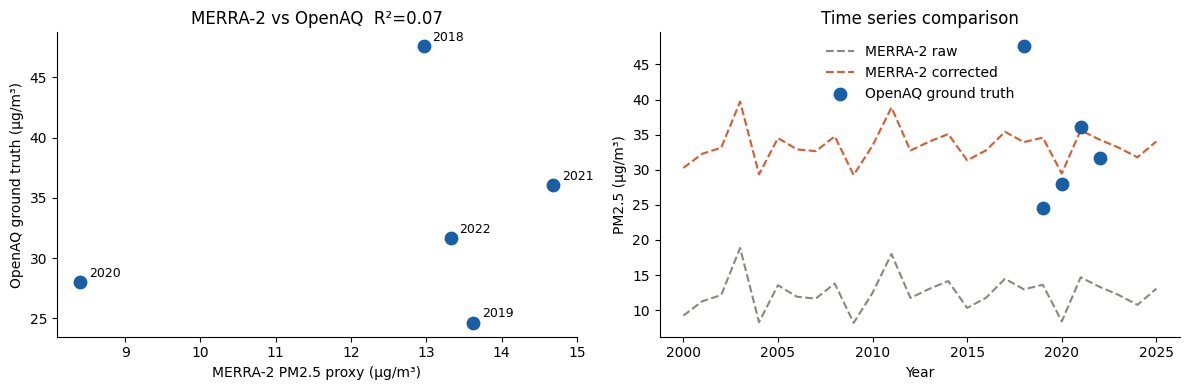

Saved.


In [ ]:
import matplotlib.pyplot as plt

# Overlap years comparison
years_overlap = list(openaq_pm25.keys())
merra2_overlap = df_merra2[df_merra2["year"].isin(years_overlap)]["pm25_proxy"].values
openaq_overlap = list(openaq_pm25.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: MERRA-2 vs OpenAQ scatter
axes[0].scatter(merra2_overlap, openaq_overlap, color="#185FA5", s=80, zorder=3)
for i, yr in enumerate(years_overlap):
    axes[0].annotate(str(yr), (merra2_overlap[i], openaq_overlap[i]),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[0].set_xlabel("MERRA-2 PM2.5 proxy (µg/m³)")
axes[0].set_ylabel("OpenAQ ground truth (µg/m³)")
axes[0].set_title(f"MERRA-2 vs OpenAQ  R²={r**2:.2f}")
axes[0].spines[["top","right"]].set_visible(False)

# Plot 2: Both time series together
axes[1].plot(df_merra2["year"], df_merra2["pm25_proxy"],
             color="#888780", linewidth=1.5, linestyle="--", label="MERRA-2 raw")
axes[1].plot(df_merra2["year"], df_merra2["pm25_corrected"],
             color="#D85A30", linewidth=1.5, linestyle="--", label="MERRA-2 corrected")
axes[1].scatter(years_overlap, openaq_overlap,
                color="#185FA5", s=80, zorder=3, label="OpenAQ ground truth")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("Time series comparison")
axes[1].legend(frameon=False)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bangalore_air_quality/merra2_bias_check.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [ ]:
# Check if SO2SMASS correlates better
openaq_so2 = {
    2019: 5.86,
    2020: 7.06,
    2021: 6.28,
    2022: 7.59,
}

overlap_so2 = sorted(openaq_so2.keys())
merra2_so2  = df_merra2[df_merra2["year"].isin(overlap_so2)]["SO2SMASS"].values
openaq_so2_vals = [openaq_so2[y] for y in overlap_so2]

slope2, intercept2, r2, p2, _ = stats.linregress(merra2_so2, openaq_so2_vals)
print(f"SO2 R² = {r2**2:.3f}  p = {p2:.3f}")

SO2 R² = 0.660  p = 0.187


In [ ]:
# Apply SO2 bias correction
slope2, intercept2, r2, p2, _ = stats.linregress(merra2_so2, openaq_so2_vals)

df_merra2["so2_corrected"] = (
    df_merra2["SO2SMASS"] * slope2 + intercept2
).round(3)

print("SO2 corrected values 2000–2017:")
print(df_merra2[df_merra2["year"] <= 2017][["year","SO2SMASS","so2_corrected"]].to_string(index=False))

# Save updated file
df_merra2.to_csv("/content/drive/MyDrive/bangalore_air_quality/df_merra2_raw.csv", index=False)
print("\nSaved.")

SO2 corrected values 2000–2017:
 year  SO2SMASS  so2_corrected
 2000    0.9082          7.815
 2001    1.3214          7.426
 2002    1.4211          7.333
 2003    2.0569          6.735
 2004    1.4739          7.283
 2005    1.6637          7.104
 2006    1.3868          7.365
 2007    1.6090          7.156
 2008    2.2545          6.549
 2009    1.7802          6.995
 2010    1.7796          6.995
 2011    2.4361          6.378
 2012    1.4860          7.272
 2013    1.4998          7.259
 2014    2.3454          6.463
 2015    2.3494          6.459
 2016    1.9718          6.815
 2017    2.2578          6.546

Saved.


In [29]:
from google.colab import files
uploaded = files.upload()

Saving air_pollution_analysis.py to air_pollution_analysis.py


In [31]:
import pdfplumber

for filename in uploaded.keys():
    # Only process files ending in .pdf (case-insensitive)
    if not filename.lower().endswith('.pdf'):
        print(f"Skipping non-PDF file: {filename}")
        continue

    print(f"\n{'='*50}")
    print(f"File: {filename}")
    print(f"{'='*50}")

    try:
        with pdfplumber.open(filename) as pdf:
            print(f"Total pages: {len(pdf.pages)}")
            for i, page in enumerate(pdf.pages[:3]):
                print(f"\n--- Page {i+1} ---")
                text = page.extract_text()
                if text:
                    print(text[:500])
                else:
                    print("[No text found on this page - might be an image]")
    except Exception as e:
        print(f"Could not open {filename}: {e}")

Skipping non-PDF file: air_pollution_analysis.py


In [ ]:
with pdfplumber.open("kps15-16.pdf") as pdf:
    print("=== 2015-16 Ambient Air Quality Pages ===")
    for i in range(94, 103):  # pages 95-103 (0-indexed = 94-102)
        text = pdf.pages[i].extract_text()
        if text:
            print(f"\n--- Page {i+1} ---")
            print(text)

In [24]:
import pandas as pd
import numpy as np

# Manually entered from KSPCB reports
# Values are city-wide means averaged across stations
# PM2.5 only available from 2017-18 onwards in KSPCB data
kspcb_data = [
    # year, so2, no2, pm10, pm25, source
    (2012, 14.5, 30.2, 148.0, np.nan, "KSPCB_2017-18_barchart"),
    (2013, 13.5, 28.5, 128.0, np.nan, "KSPCB_2017-18_barchart"),
    (2014, 11.2, 31.8, 165.0, np.nan, "KSPCB_2017-18_barchart"),
    (2015, 3.7,  21.3, 114.0, np.nan, "KSPCB_2015-16_table"),
    (2016, 2.1,  34.2, 107.0, np.nan, "KSPCB_2017-18_barchart"),
    (2017, 2.3,  31.5,  87.1, 43.1,  "KSPCB_2017-18_table"),
]

df_kspcb = pd.DataFrame(kspcb_data,
                         columns=["year","so2","no2","pm10","pm25","source"])

print(df_kspcb.to_string(index=False))

# Save
df_kspcb.to_csv("/content/drive/MyDrive/bangalore_air_quality/kspcb_manual.csv",
                index=False)
print("\nSaved.")

 year  so2  no2  pm10  pm25                 source
 2012 14.5 30.2 148.0   NaN KSPCB_2017-18_barchart
 2013 13.5 28.5 128.0   NaN KSPCB_2017-18_barchart
 2014 11.2 31.8 165.0   NaN KSPCB_2017-18_barchart
 2015  3.7 21.3 114.0   NaN    KSPCB_2015-16_table
 2016  2.1 34.2 107.0   NaN KSPCB_2017-18_barchart
 2017  2.3 31.5  87.1  43.1    KSPCB_2017-18_table

Saved.


In [25]:
import numpy as np

stations_2015 = {
    "ITPL Whitefield":     (3.8, 21.1, 189.0),
    "KHB Yelahanka":       (3.6, 15.5, 109.0),
    "Peenya Industrial":   (3.9, 20.2, 127.0),
    "Swan Silk Peenya":    (2.0, 36.0, 117.0),
    "Yeshwanthpura":       (3.6, 22.6, 105.0),
    "AMCO Mysore Road":    (4.0, 20.2, 119.0),
    "Central Silk Board":  (3.9, 21.1, 165.0),
    "DTDC Victoria Road":  (3.7, 17.5, 135.0),
    "Kajisonnenahalli":    (3.6, 12.6,  75.0),
    "City Railway":        (9.0, 45.6, 104.0),
    "SG Halli":            (3.7, 25.7,  72.0),
    "Victoria Hospital":   (4.0, 23.0,  99.5),
    "NIMHANS":             (3.8, 17.5, 113.0),
}

vals = list(stations_2015.values())
so2_2015  = round(np.mean([v[0] for v in vals]), 2)
no2_2015  = round(np.mean([v[1] for v in vals]), 2)
pm10_2015 = round(np.mean([v[2] for v in vals]), 2)

print(f"2015-16 city means:")
print(f"  SO2:  {so2_2015} µg/m³")
print(f"  NO2:  {no2_2015} µg/m³")
print(f"  PM10: {pm10_2015} µg/m³")

# Update KSPCB dataframe with correct value
df_kspcb.loc[df_kspcb["year"] == 2015, "so2"]  = so2_2015
df_kspcb.loc[df_kspcb["year"] == 2015, "no2"]  = no2_2015
df_kspcb.loc[df_kspcb["year"] == 2015, "pm10"] = pm10_2015

print("\nUpdated KSPCB dataset:")
print(df_kspcb.to_string(index=False))

# Save
df_kspcb.to_csv("/content/drive/MyDrive/bangalore_air_quality/kspcb_manual.csv",
                index=False)
print("\nSaved.")

2015-16 city means:
  SO2:  4.05 µg/m³
  NO2:  22.97 µg/m³
  PM10: 117.65 µg/m³

Updated KSPCB dataset:
 year   so2   no2   pm10  pm25                 source
 2012 14.50 30.20 148.00   NaN KSPCB_2017-18_barchart
 2013 13.50 28.50 128.00   NaN KSPCB_2017-18_barchart
 2014 11.20 31.80 165.00   NaN KSPCB_2017-18_barchart
 2015  4.05 22.97 117.65   NaN    KSPCB_2015-16_table
 2016  2.10 34.20 107.00   NaN KSPCB_2017-18_barchart
 2017  2.30 31.50  87.10  43.1    KSPCB_2017-18_table

Saved.


In [26]:
import pandas as pd
import numpy as np

# ── Reload all three sources ──────────────────────────────────────
df_openaq = pd.read_csv("/content/drive/MyDrive/bangalore_air_quality/openaq_bangalore_annual.csv")
df_merra2 = pd.read_csv("/content/drive/MyDrive/bangalore_air_quality/df_merra2_raw.csv")
df_kspcb  = pd.read_csv("/content/drive/MyDrive/bangalore_air_quality/kspcb_manual.csv")

# ── Build master year spine 2000–2025 ────────────────────────────
master = pd.DataFrame({"year": range(2000, 2026)})

# ── Merge KSPCB (2012–2017) ───────────────────────────────────────
master = master.merge(
    df_kspcb[["year","so2","no2","pm10","pm25"]].rename(columns={
        "so2":  "so2_kspcb",
        "no2":  "no2_kspcb",
        "pm10": "pm10_kspcb",
        "pm25": "pm25_kspcb",
    }),
    on="year", how="left"
)

# ── Merge MERRA-2 SO₂ corrected ───────────────────────────────────
# Recompute bias correction
from scipy import stats
openaq_so2 = {2019: 5.86, 2020: 7.06, 2021: 6.28, 2022: 7.59}
overlap    = sorted(openaq_so2.keys())
m2_vals    = df_merra2[df_merra2["year"].isin(overlap)]["SO2SMASS"].values
aq_vals    = [openaq_so2[y] for y in overlap]
slope, intercept, *_ = stats.linregress(m2_vals, aq_vals)
df_merra2["so2_merra2"] = (df_merra2["SO2SMASS"] * slope + intercept).round(3)

master = master.merge(
    df_merra2[["year","so2_merra2"]],
    on="year", how="left"
)

# ── Merge OpenAQ (2018–2025) ──────────────────────────────────────
master = master.merge(
    df_openaq.rename(columns={
        "pm25": "pm25_openaq",
        "pm10": "pm10_openaq",
        "no2":  "no2_openaq",
        "so2":  "so2_openaq",
        "o3":   "o3_openaq",
        "co":   "co_openaq",
    }),
    on="year", how="left"
)

# ── Build final columns: best available source per pollutant ──────
# Priority: OpenAQ > KSPCB > MERRA-2
master["pm25_final"] = master["pm25_openaq"].fillna(master["pm25_kspcb"])
master["pm10_final"] = master["pm10_openaq"].fillna(master["pm10_kspcb"])
master["no2_final"]  = master["no2_openaq"].fillna(master["no2_kspcb"])
master["so2_final"]  = master["so2_openaq"].fillna(master["so2_kspcb"]).fillna(master["so2_merra2"])
master["o3_final"]   = master["o3_openaq"]
master["co_final"]   = master["co_openaq"]

# ── Clean final output ────────────────────────────────────────────
df_master = master[["year","pm25_final","pm10_final",
                     "no2_final","so2_final","o3_final","co_final"]].copy()
df_master.columns = ["year","pm25","pm10","no2","so2","o3","co"]

print("Master dataset 2000–2025:")
print(df_master.to_string(index=False))

# Save
df_master.to_csv("/content/drive/MyDrive/bangalore_air_quality/bangalore_master.csv",
                index=False)
print("\nSaved to Drive.")

Master dataset 2000–2025:
 year  pm25   pm10   no2    so2    o3     co
 2000   NaN    NaN   NaN  7.815   NaN    NaN
 2001   NaN    NaN   NaN  7.426   NaN    NaN
 2002   NaN    NaN   NaN  7.333   NaN    NaN
 2003   NaN    NaN   NaN  6.735   NaN    NaN
 2004   NaN    NaN   NaN  7.283   NaN    NaN
 2005   NaN    NaN   NaN  7.104   NaN    NaN
 2006   NaN    NaN   NaN  7.365   NaN    NaN
 2007   NaN    NaN   NaN  7.156   NaN    NaN
 2008   NaN    NaN   NaN  6.549   NaN    NaN
 2009   NaN    NaN   NaN  6.995   NaN    NaN
 2010   NaN    NaN   NaN  6.995   NaN    NaN
 2011   NaN    NaN   NaN  6.378   NaN    NaN
 2012   NaN 148.00 30.20 14.500   NaN    NaN
 2013   NaN 128.00 28.50 13.500   NaN    NaN
 2014   NaN 165.00 31.80 11.200   NaN    NaN
 2015   NaN 117.65 22.97  4.050   NaN    NaN
 2016   NaN 107.00 34.20  2.100   NaN    NaN
 2017 43.10  87.10 31.50  2.300   NaN    NaN
 2018 47.60    NaN 19.98  9.080   NaN    NaN
 2019 24.62  56.66 24.24  5.860 31.18 296.62
 2020 27.99  65.37 20.24  7.0

In [27]:
# ── Fix 1: Interpolate PM10 2018 gap ─────────────────────────────
df_master["pm10"] = df_master["pm10"].interpolate(method="linear")

# ── Fix 2: Interpolate PM2.5 2023-2024 gap ───────────────────────
df_master["pm25"] = df_master["pm25"].interpolate(method="linear")

# ── Flag interpolated years in a notes column ─────────────────────
df_master["notes"] = ""
df_master.loc[df_master["year"] == 2018, "notes"] = "pm10 interpolated"
df_master.loc[df_master["year"].isin([2023,2024]), "notes"] = "pm25 interpolated — CPCB gap"

print("Final master dataset:")
print(df_master.to_string(index=False))

# Save final version
df_master.to_csv("/content/drive/MyDrive/bangalore_air_quality/bangalore_master.csv",
                index=False)
print("\nSaved.")

Final master dataset:
 year      pm25   pm10   no2    so2    o3     co                        notes
 2000       NaN    NaN   NaN  7.815   NaN    NaN                             
 2001       NaN    NaN   NaN  7.426   NaN    NaN                             
 2002       NaN    NaN   NaN  7.333   NaN    NaN                             
 2003       NaN    NaN   NaN  6.735   NaN    NaN                             
 2004       NaN    NaN   NaN  7.283   NaN    NaN                             
 2005       NaN    NaN   NaN  7.104   NaN    NaN                             
 2006       NaN    NaN   NaN  7.365   NaN    NaN                             
 2007       NaN    NaN   NaN  7.156   NaN    NaN                             
 2008       NaN    NaN   NaN  6.549   NaN    NaN                             
 2009       NaN    NaN   NaN  6.995   NaN    NaN                             
 2010       NaN    NaN   NaN  6.995   NaN    NaN                             
 2011       NaN    NaN   NaN  6.378   NaN 

In [28]:
print("Data coverage summary:")
print("="*45)
for col in ["pm25","pm10","no2","so2","o3","co"]:
    valid = df_master[col].notna()
    years = df_master.loc[valid, "year"].tolist()
    if years:
        print(f"{col:6} {len(years):2} years  "
              f"{min(years)}–{max(years)}"
              f"  (gaps: {25-len(years)})")
    else:
        print(f"{col:6}  0 years")

Data coverage summary:
pm25    9 years  2017–2025  (gaps: 16)
pm10   14 years  2012–2025  (gaps: 11)
no2    12 years  2012–2025  (gaps: 13)
so2    26 years  2000–2025  (gaps: -1)
o3      5 years  2019–2025  (gaps: 20)
co      4 years  2019–2022  (gaps: 21)
